# Day 14 of ML 30-Days Challenge

# Task

**Decision Tree Regression**: Understand how decision trees work for regression tasks by recursively splitting the data. Learn to visualize the tree structure to make the model's predictions interpretable and transparent.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

###1. Create a non-linear dataset

In [56]:
rng = np.random.RandomState(42)
n = 100 # the larger is better for better acr. but takes more time
X = rng.uniform(0, 10, size=(n, 1))

y_true_fn = ( 2.0 * np.sin(X[:, 0]) + 0.5 * (X[:, 0] > 3) - 0.8 * (X[:, 0] > 7) + 0.05 * (X[:, 0] - 5) ** 2 )
noise = rng.normal(0, 0.3, size=n)
y = y_true_fn + noise

df = pd.DataFrame({"x": X[:, 0], "y": y})

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

df.describe()

,x,y
count,100.000000,100.000000
mean,4.701807,1.022521
std,2.974894,1.356104
min,0.055221,-1.891996
25%,1.932008,-0.034507
50%,4.641425,1.408828
75%,7.302031,2.120292
max,9.868869,3.205644


###2. Implementing a Single Decision Tree Model

In [57]:
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

###3. Visualizing the Tree's Predictions (1-D)

In [58]:
x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
y_pred_full_grid = tree_full.predict(x_grid)

y_pred_full_test = tree_full.predict(X_test)

mse_full = mean_squared_error(y_test, y_pred_full_test)
r2_full = r2_score(y_test, y_pred_full_test)

print(f"Full-depth tree -> Test MSE: {mse_full:.4f}, R2: {r2_full:.4f}")

Full-depth tree -> Test MSE: 0.0986, R2: 0.9305


###4. Visualizing the Tree Structure (plot_tree)

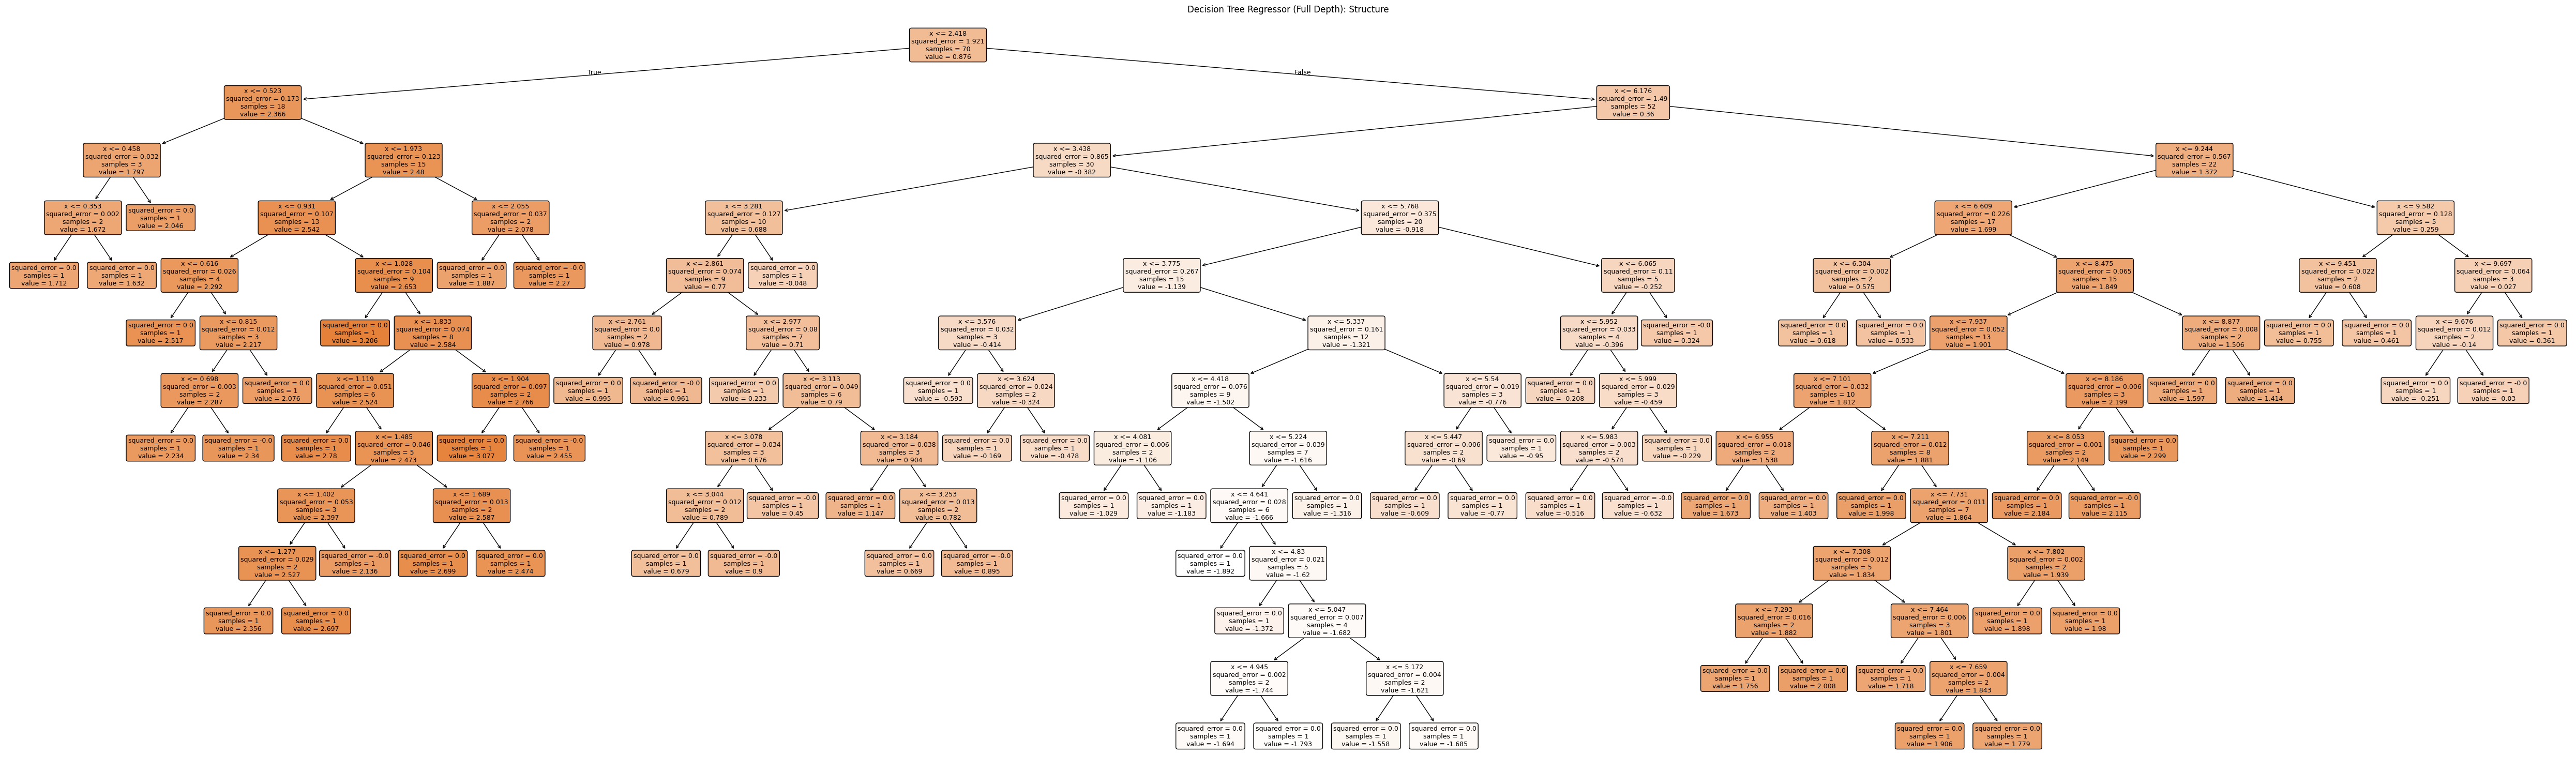

In [59]:
# to those who have learned binary tree
plt.figure(figsize=(50, 15))
plot_tree( tree_full, feature_names=["x"], filled=True, rounded=True, fontsize=9 )
plt.title("Decision Tree Regressor (Full Depth): Structure")
plt.tight_layout()
plt.show()

###5. Controlling Complexity: Train with a smaller max_depth=3

In [60]:
# if you go with simpler and broader category then set max_depth
tree_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_shallow.fit(X_train, y_train)

y_pred_shallow_grid = tree_shallow.predict(x_grid)
y_pred_shallow_test = tree_shallow.predict(X_test)

mse_shallow = mean_squared_error(y_test, y_pred_shallow_test)
r2_shallow = r2_score(y_test, y_pred_shallow_test)

print(f"Shallow tree (max_depth=3) -> Test MSE: {mse_shallow:.4f}, R2: {r2_shallow:.4f}")

Shallow tree (max_depth=3) -> Test MSE: 0.2259, R2: 0.8409


###6. Visualize the Shallow Tree Structure (just for you)

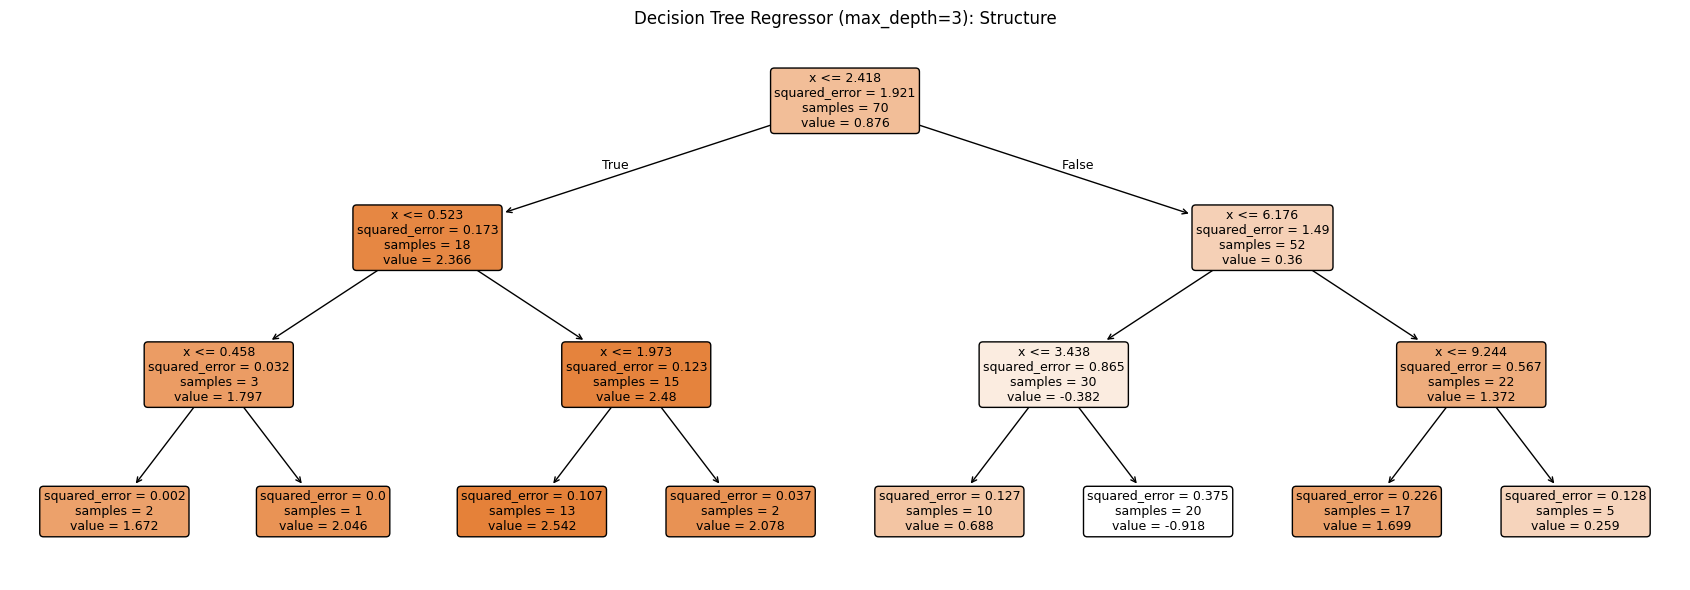

In [61]:
plt.figure(figsize=(17, 6))
plot_tree( tree_shallow, feature_names=["x"], filled=True, rounded=True, fontsize=9 )
plt.title("Decision Tree Regressor (max_depth=3): Structure")
plt.tight_layout()
plt.show()

###7. Final Visualizations: Data + Both Model Predictions

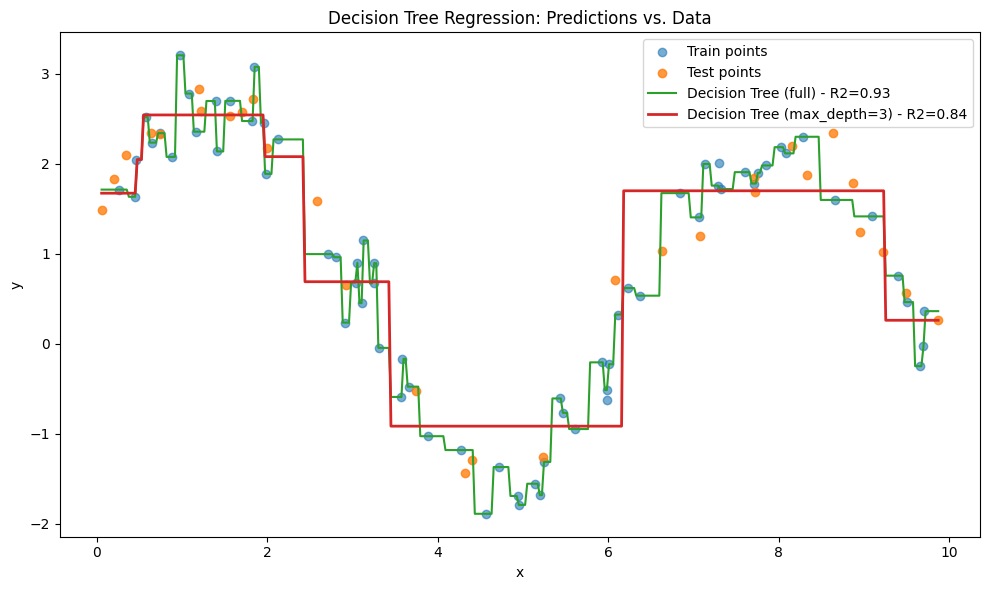

In [62]:
plt.figure(figsize=(10, 6))

plt.scatter(X_train[:, 0], y_train, color="tab:blue", alpha=0.6, label="Train points")
plt.scatter(X_test[:, 0], y_test, color="tab:orange", alpha=0.8, label="Test points")

# full-depth tree predictions
plt.plot(x_grid[:, 0], y_pred_full_grid, color="tab:green", label=f"Decision Tree (full) - R2={r2_full:.2f}")

# shallow tree predictions
plt.plot(x_grid[:, 0], y_pred_shallow_grid, color="tab:red", lw=2, label=f"Decision Tree (max_depth=3) - R2={r2_shallow:.2f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Decision Tree Regression: Predictions vs. Data")
plt.legend()
plt.tight_layout()
plt.show()